Підготовка: Завантаження бібліотек та даних

In [2]:
import pandas as pd
import numpy as np

# Завантажую дані з параметром low_memory, щоб уникнути попереджень про типи даних
df = pd.read_csv('survey_results_public.csv', low_memory=False)
schema = pd.read_csv('survey_results_schema.csv')

# Перевірка наявності ключових колонок
print("Колонки в датасеті:", df.columns.tolist()[:10]) # Перші 10 назв

Колонки в датасеті: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI']


Завдання 1. Підрахунок загальної кількості респондентів

In [3]:
# Підрахунок респондентів
total_res = len(df)
print(f"Загальна кількість респондентів: {total_res}")

Загальна кількість респондентів: 49191


Завдання 2. Аналіз повноти відповідей

In [4]:
# 1. Унікальні назви питань зі схеми (стовпець qname)
questions_in_schema = set(schema['qname'].unique())

# 2. Назви колонок, які реально є в таблиці з відповідями
columns_in_df = set(df.columns)

# 3. Пошук перетину (тільки ті питання, що є і там, і там)
common_cols = list(questions_in_schema.intersection(columns_in_df))

# 4. Фільтрація респондентів, які не мають жодного пропуску в цих колонках
valid_rows = df.dropna(subset=common_cols)

print(f"Кількість питань для аналізу: {len(common_cols)}")
print(f"Респондентів без жодного пропуску: {len(valid_rows)}")

Кількість питань для аналізу: 126
Респондентів без жодного пропуску: 0


Завдання 3. Статистичний аналіз досвіду (WorkExp)

In [5]:
# Обчислення: середнє, медіана та мода
mean_exp = df['WorkExp'].mean()
median_exp = df['WorkExp'].median()
mode_exp = df['WorkExp'].mode()[0]

# Вивід результату у більш структурованому форматі
work_exp_stats = pd.DataFrame({
    'Показник': ['Середнє (Mean)', 'Медіана (Median)', 'Мода (Mode)'],
    'Значення (роки)': [round(mean_exp, 2), median_exp, mode_exp]
})

print(work_exp_stats.to_string(index=False))

        Показник  Значення (роки)
  Середнє (Mean)            13.37
Медіана (Median)            10.00
     Мода (Mode)            10.00


Завдання 4. Аналіз віддаленої роботи

In [6]:
# Підраховую кількість респондентів за форматом роботи
# Дивлюся на унікальні значення, щоб впевнитись у назві
print("Варіанти відповідей у RemoteWork:", df['RemoteWork'].unique())

# Фільтрація та підрахунок
remote_count = df[df['RemoteWork'] == 'Remote'].shape[0]

print(f"\nЗагальна кількість віддалених працівників: {remote_count}")

Варіанти відповідей у RemoteWork: ['Remote' 'Hybrid (some in-person, leans heavy to flexibility)' nan
 'In-person' 'Hybrid (some remote, leans heavy to in-person)'
 'Your choice (very flexible, you can come in when you want or just as needed)']

Загальна кількість віддалених працівників: 10931


Завдання 5. Визначення популярності Python

In [7]:
# 1. Пошук тих, хто використовує Python
python_users_mask = df['LanguageHaveWorkedWith'].str.contains('Python', na=False)
python_count = python_users_mask.sum()

# 2. Рахую відсоток від загальної кількості респондентів
total_respondents = len(df)
python_percentage = (python_count / total_respondents) * 100

print(f"Кількість Python-розробників: {python_count}")
print(f"Відсоток від усіх респондентів: {python_percentage:.2f}%")

Кількість Python-розробників: 18466
Відсоток від усіх респондентів: 37.54%


Завдання 6. Аналіз шляхів навчання (Онлайн курси)

In [8]:
# Пошук згадки 'Online Courses' у колонці LearnCode
online_train_mask = df['LearnCode'].str.contains('Online Courses', na=False)
online_train_count = online_train_mask.sum()

print(f"Кількість респондентів, що навчалися через онлайн-курси: {online_train_count}")

Кількість респондентів, що навчалися через онлайн-курси: 10973


Завдання 7. Географічний аналіз компенсації Python-розробників

In [9]:
# 1. Створюю окремий датафрейм лише з Python-розробниками
python_devs = df[df['LanguageHaveWorkedWith'].str.contains('Python', na=False)].copy()

# 2. Групую за країною та рахую середнє та медіану для ConvertedCompYearly
# Видаляю NaN у компенсації, щоб вони не псували статистику
country_stats = python_devs.dropna(subset=['ConvertedCompYearly']).groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median']).reset_index()

# 3. Перейменовую стовпці для гарнокращого подання
country_stats.columns = ['Країна', 'Середня компенсація', 'Медіанна компенсація']

# Вивід перших 10 країн
print("Статистика компенсації Python-розробників по країнах:")
display(country_stats.head(10))

Статистика компенсації Python-розробників по країнах:


,Країна,Середня компенсація,Медіанна компенсація
0,Afghanistan,22328.666667,1000.0
1,Albania,47217.600000,50000.0
2,Algeria,20187.285714,7088.0
3,Andorra,226103.500000,226103.5
4,Antigua and Barbuda,1.000000,1.0
5,Argentina,47080.207792,40000.0
6,Armenia,19093.400000,2075.0
7,Australia,118091.410423,97514.0
8,Austria,78558.388489,75410.0
9,Azerbaijan,23445.333333,29397.0


Завдання 8. Аналіз освіти найбільш оплачуваних спеціалістів

In [10]:
# 1. Сортую весь датасет за компенсацією від більшої до меншої
# 2. Беру перші 5 записів
top_5_rich = df.sort_values(by='ConvertedCompYearly', ascending=False).head(5)

# 3. Вибираю стовпець EdLevel (рівень освіти)
top_education = top_5_rich[['ConvertedCompYearly', 'EdLevel']]

print("Рівень освіти 5 найоплачуваніших респондентів:")
display(top_education)

Рівень освіти 5 найоплачуваніших респондентів:


,ConvertedCompYearly,EdLevel
34267,50000000.0,"Associate degree (A.A., A.S., etc.)"
28700,33552715.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
43143,18387548.0,"Associate degree (A.A., A.S., etc.)"
35353,15430267.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
45971,13921760.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"


*Завдання 9. Популярність Python по вікових категоріях

In [11]:
# Групую по Age та рахуєю відсоток Python-користувачів
age_python_stats = df.groupby('Age')['LanguageHaveWorkedWith'].apply(
    lambda x: (x.str.contains('Python', na=False).sum() / len(x)) * 100
).reset_index()

age_python_stats.columns = ['Вікова категорія', 'Відсоток Python (%)']

print("Популярність Python за віковими групами:")
display(age_python_stats.sort_values(by='Відсоток Python (%)', ascending=False))

Популярність Python за віковими групами:


,Вікова категорія,Відсоток Python (%)
0,18-24 years old,40.000000
3,45-54 years old,38.629482
4,55-64 years old,37.242955
1,25-34 years old,36.939282
2,35-44 years old,36.719281
5,65 years or older,31.634820
6,Prefer not to say,31.216931


*Завдання 10. Індустрії високооплачуваних віддалених працівників

In [12]:
# 1. Шукаю поріг 75-го перцентиля компенсації
q75_threshold = df['ConvertedCompYearly'].quantile(0.75)

# 2. Фільтрація: зарплата > q75 ТА віддалена робота
high_paid_remote_df = df[(df['ConvertedCompYearly'] > q75_threshold) & (df['RemoteWork'] == 'Remote')]

# 3. Підраховую найпопулярніші індустрії
top_industries = high_paid_remote_df['Industry'].value_counts().reset_index()
top_industries.columns = ['Індустрія', 'Кількість респондентів']

print(f"75-й перцентиль компенсації: {q75_threshold:.2f}")
print("\nНайпопулярніші індустрії серед багатих віддалеників:")
display(top_industries.head(10))

75-й перцентиль компенсації: 120596.00

Найпопулярніші індустрії серед багатих віддалеників:


,Індустрія,Кількість респондентів
0,Software Development,1186
1,Fintech,190
2,Healthcare,188
3,Other:,176
4,"Internet, Telecomm or Information Services",138
5,Banking/Financial Services,88
6,Government,78
7,Media & Advertising Services,75
8,Retail and Consumer Services,65
9,"Transportation, or Supply Chain",63


Фінальний висновок за результатами аналізу Stack Overflow Survey 2025
У ході виконання проєкту було проаналізовано дані понад 49,000 респондентів. Основні результати дослідження:

1. Популярність Python та навчання
Python залишається однією з провідних мов програмування, яку використовують 37.54% опитаних.

Найвищий рівень популярності Python спостерігається у молодих фахівців віком 18-24 роки (40%), що підтверджує роль цієї мови як основного інструменту для навчання та входу в індустрію. Зі збільшенням віку відсоток використання дещо знижується, але залишається стабільно високим (понад 30%).

Значна частина спільноти (майже 11 тисяч осіб) використовувала онлайн-курси як один зі шляхів навчання, що підкреслює важливість неформальної освіти в IT.

2. Компенсація та географія
Аналіз зарплат Python-розробників показав значну нерівномірність. У багатьох країнах (наприклад, Афганістан) спостерігається великий розрив між середнім значенням та медіаною, що свідчить про наявність одиничних "високих" контрактів на фоні низьких загальних показників. Медіана виявилася більш надійною мірою центральної тенденції.

Найвищі рівні медіанної компенсації зафіксовані в Австралії, Андоррі та Австрії (серед перших десяти країн списку).

3. Портрет високооплачуваного спеціаліста
П'ять найбільш оплачуваних респондентів мають рівні освіти від Associate degree до Master’s degree. Це свідчить про те, що в топі доходів цінується не лише формальний ступінь, а й прикладні навички.

Серед найбільш оплачуваних фахівців (75-й перцентиль), які працюють віддалено, домінуючою індустрією є Software Development (1186 осіб). Також значну частку займають Fintech та Healthcare, що вказує на готовність цих секторів платити високу ціну за гнучкість та кваліфікацію.

4. Повнота даних
Дослідження показало, що жоден респондент не відповів на всі 126 запитань опитування. Це підтверджує складну структуру анкетування з багатьма логічними розгалуженнями, де частина питань є специфічною для конкретних ролей.

Популярність Python за віком (Bar Chart)

C:\Users\krivo\AppData\Local\Temp\ipykernel_23936\613776343.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=age_python_stats, x='Вікова категорія', y='Відсоток Python (%)', palette='viridis')


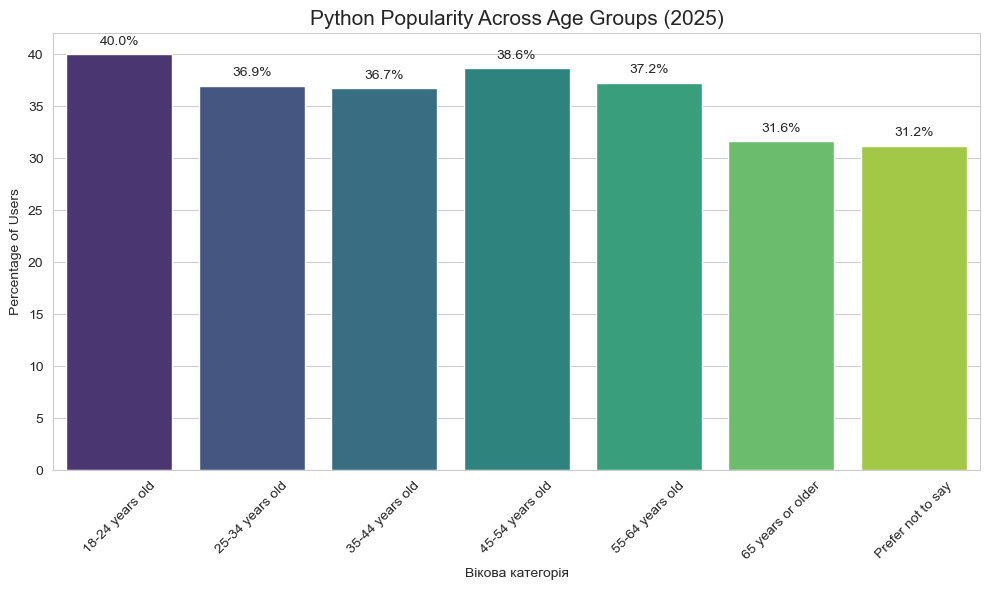

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Використовуємо дані з Завдання 9
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Робимо чистий білий фон з сіткою

# Створюємо графік
ax = sns.barplot(data=age_python_stats, x='Вікова категорія', y='Відсоток Python (%)', palette='viridis')

# Додаємо підписи значень над стовпчиками
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Python Popularity Across Age Groups (2025)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Percentage of Users')
plt.tight_layout()
plt.show()

Топ індустрій для віддаленої роботи (Horizontal Bar Chart)

C:\Users\krivo\AppData\Local\Temp\ipykernel_23936\782169615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_industries.head(10), x='Кількість респондентів', y='Індустрія', palette='magma')


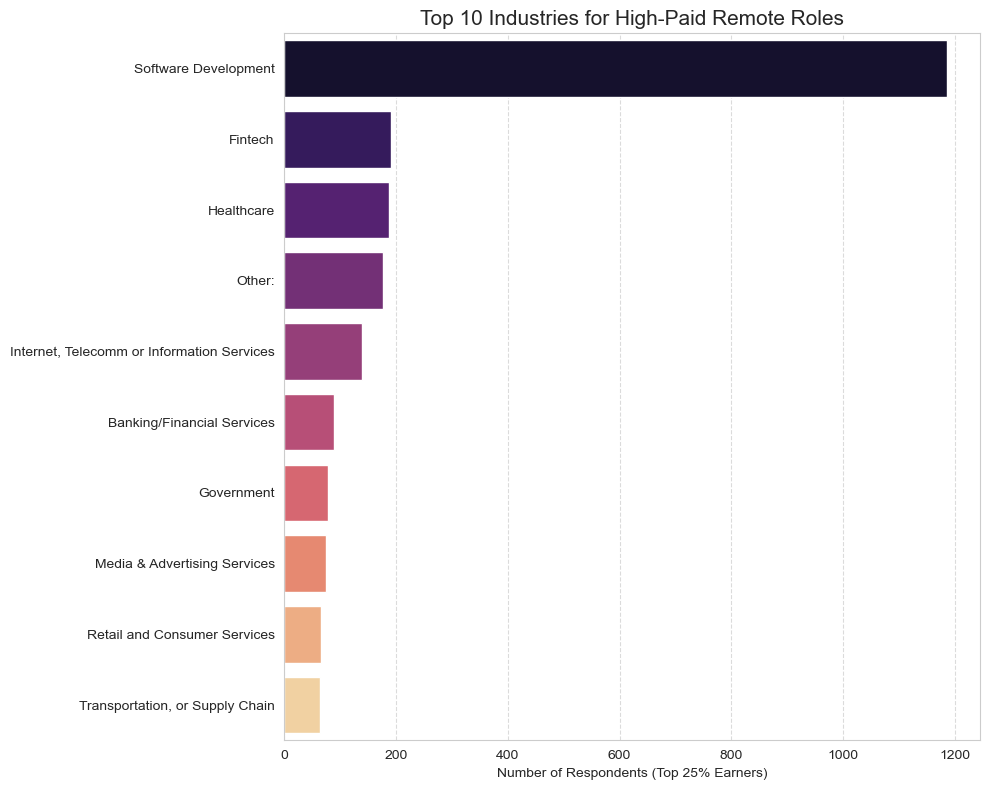

In [ ]:
plt.figure(figsize=(10, 8))
# Беремо топ-10 з Завдання 10
sns.barplot(data=top_industries.head(10), x='Кількість респондентів', y='Індустрія', palette='magma')

plt.title('Top 10 Industries for High-Paid Remote Roles', fontsize=15)
plt.xlabel('Number of Respondents (Top 25% Earners)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()